# 📊 Practice: Normal Distribution & Central Limit Theorem
> **Topics:** Probability, distributions & Central Limit Theorem 
> **Author:** José Reyes  
> **Date:** September 3rd, 2026 

---

### 🎯 Objective
Simulate a casino roulette to demonstrate how CLT can affect financial outputs at large range of tries with a normal distribution.

---

### 📋 Notebook Structure
1. **Env config:** Library imports and seeds.

---

# 1. Libraries

In [40]:
from scipy.stats import norm
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt

# 2. Creating the European Wheel

In [41]:
# Creating an European roulette wheel in a DataFrame

zero = pd.DataFrame({
    'number': [0],
    'color': ['green']
})

red_numbers = pd.DataFrame({
    'number': [1, 3, 5, 7, 9, 12, 14, 16, 18, 19, 21, 23, 25, 27, 30, 32, 34, 36],
    'color': ['red'] * 18
})

black_numbers = pd.DataFrame({
    'number': [2, 4, 6, 8, 10, 11, 13, 15, 17, 20, 22, 24, 26, 28, 29, 31, 33, 35],
    'color': ['black'] * 18
})

european_roulette_wheel = pd.concat([zero, red_numbers, black_numbers], ignore_index=True)

In [42]:
european_roulette_wheel.shape

(37, 2)

In [43]:
european_roulette_wheel.head()

,number,color
0,0,green
1,1,red
2,3,red
3,5,red
4,7,red


# 3. Simulating

First, we will add a new column with the probabilities of each outcome

$$P(Pocket)=\frac{1}{37}=0.027$$

In [44]:
# Adding a probe column for each pocket probability
european_roulette_wheel['probe'] = european_roulette_wheel['number'].apply(lambda x: round(1/len(european_roulette_wheel), 3))

In [45]:
sum(european_roulette_wheel['probe'])

0.999

Every pocket in the European roulette has a single probability of 0.027 (2.7%) to happen.

The sum of all probabilities inside the wheel, are close to 1 (or 100)

## 3.1 Discrete Uniform Distribution

Describing the probability of each income scenario.

In [46]:
uniform_dist = european_roulette_wheel[['number', 'probe']]

# Visualizing the uniform distribution
uniform_dist_fig = px.bar(
    uniform_dist,
    x='number',
    y='probe',
    title='Probability Distribution of European Roulette Wheel',
    labels={
        'number': 'Pocket',
        'probe': 'Probability'
        }
    )

uniform_dist_fig.show()

## 3.2 Calculating the Expected Value (EV)

Calculating the **Expected Value (EV)** of a fair spin:

$$\sum_{i=0}^{36} (i\times\frac{1}{37}) = (1\times\frac{1}{37}) + (2\times\frac{1}{37}) + (3\times\frac{1}{37}) + ... + (36\times\frac{1}{37}) = 18$$

In [47]:
np.sum(european_roulette_wheel['number'] * european_roulette_wheel['probe'])

np.float64(17.982)

Or...

In [48]:
np.mean(european_roulette_wheel['number'])

np.float64(18.0)

## 3.3 Simulating Samples (spins)

### 3.3.1 Sampling 10 wheel spins

In [49]:
# Simulating 10 spins
spins_10 = european_roulette_wheel[['number', 'color']].sample(n=10, replace=True)

In [50]:
spins_10

,number,color
28,20,black
4,7,red
13,25,red
17,34,red
3,5,red
32,28,black
19,2,black
12,23,red
35,33,black
3,5,red


In [51]:
# Color distribution of the 10 spins
spins_10['color'].value_counts().reset_index()

,color,count
0,red,6
1,black,4


<Axes: >

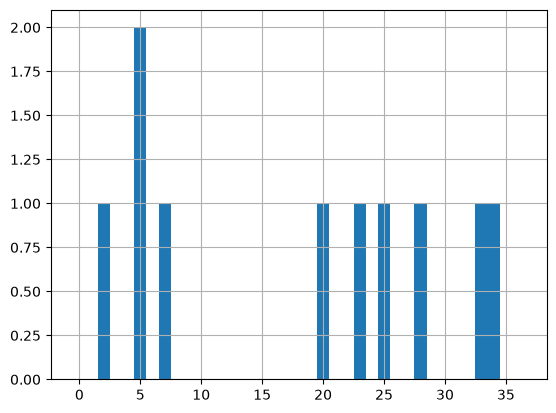

In [52]:
# Distribution of the 10 spins (numbers)
spins_10['number'].hist(bins=np.arange(-0.5, 37.5, 1))

In [53]:
ev = np.mean(european_roulette_wheel['number'])
spins_10_ev = np.mean(spins_10['number'])

print(f'Theoretical Expected Value of the European Roulette Wheel: {ev}')
print(f'Expected Value of the 10 Spins: {spins_10_ev}')

Theoretical Expected Value of the European Roulette Wheel: 18.0
Expected Value of the 10 Spins: 18.2


The expected values of samples is far from the expected value of the wheel

### 3.3.2 Now, sampling 1000 times

In [54]:
# Simulating 1000 spins
spins_1000 = european_roulette_wheel[['number', 'color']].sample(n=1000, replace=True)

In [55]:
# Color distribution of the 1000 spins
spins_1000['color'].value_counts().reset_index()

,color,count
0,black,503
1,red,472
2,green,25


<Axes: >

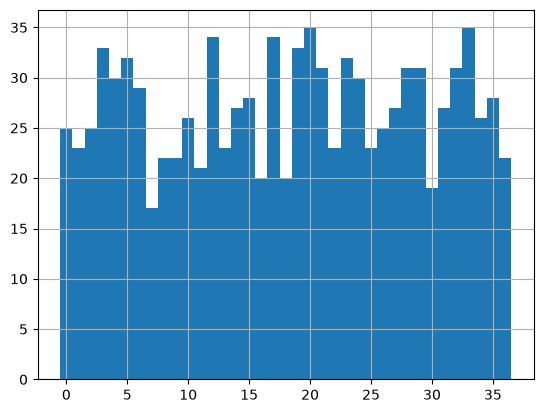

In [56]:
# Distribution of the 1000 spins (numbers)
spins_1000['number'].hist(bins=np.arange(-0.5, 37.5, 1))

In [57]:
spins_1000_ev = np.mean(spins_1000['number'])

print(f'Theoretical Expected Value of the European Roulette Wheel: {ev}')
print(f'Expected Value of the 10000 Spins: {spins_1000_ev}')

Theoretical Expected Value of the European Roulette Wheel: 18.0
Expected Value of the 10000 Spins: 18.244


The Expected Value of 1000 spins is closer to 18.0 

Also, the distribution is closer to a uniform distribution

### 3.3.3 Now, 10K samples

In [58]:
# Simulating 10000 spins
spins_10k = european_roulette_wheel[['number', 'color']].sample(n=10000, replace=True)

In [59]:
# Color distribution of the 1000 spins
spins_10k['color'].value_counts().reset_index()

,color,count
0,black,4879
1,red,4877
2,green,244


<Axes: >

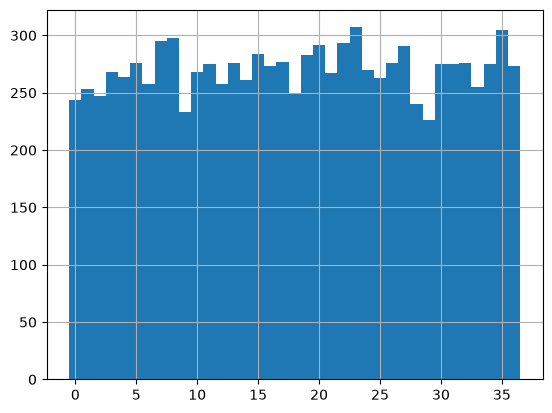

In [60]:
# Distribution of the 10000 spins (numbers)
spins_10k['number'].hist(bins=np.arange(-0.5, 37.5, 1))

In [61]:
spins_10k_ev = np.mean(spins_10k['number'])

print(f'Theoretical Expected Value of the European Roulette Wheel: {ev}')
print(f'Expected Value of the 10000 Spins: {spins_10k_ev}')

Theoretical Expected Value of the European Roulette Wheel: 18.0
Expected Value of the 10000 Spins: 18.1529


The EV is very close to 18, and the distribution is almost uniform

## 3.3.4 Law of the Large Numbers

The law of large numbers is a theorem in probability and statistics stating that as a sample size grows, its average gets closer to the true average of the whole population. 

In [62]:
lln_df = pd.DataFrame({
    'Samples': [10, 1000, 10000],
    'Expected Value': [spins_10_ev, spins_1000_ev, spins_10k_ev]
})

lln_df

,Samples,Expected Value
0,10,18.2000
1,1000,18.2440
2,10000,18.1529


**How does this affect of influences our chances/odds of winning?**

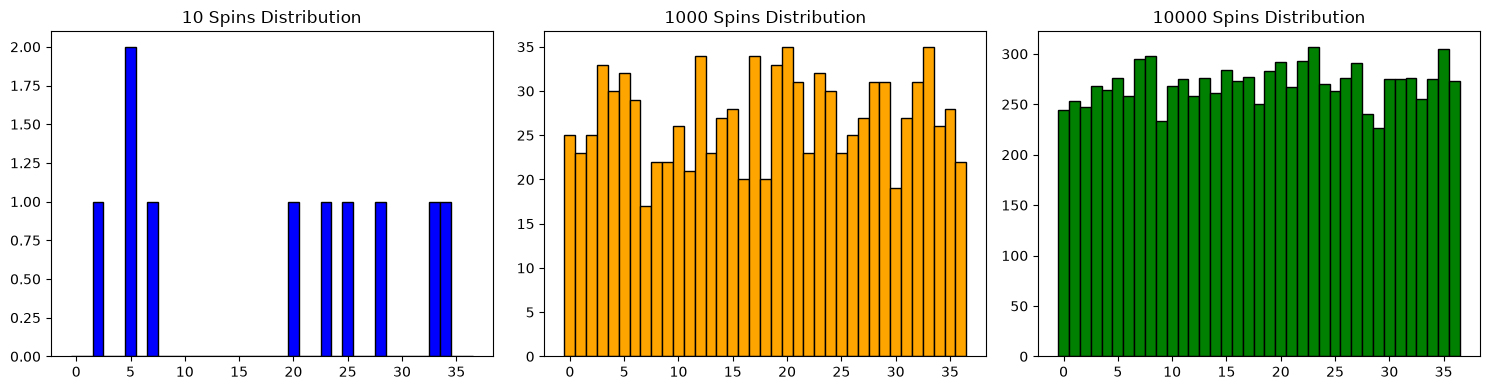

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

mis_bins = np.arange(-0.5, 37.5, 1)

axes[0].hist(spins_10['number'], bins=mis_bins, color='blue', edgecolor='black')
axes[0].set_title('10 Spins Distribution')

axes[1].hist(spins_1000['number'], bins=mis_bins, color='orange', edgecolor='black')
axes[1].set_title('1000 Spins Distribution')

axes[2].hist(spins_10k['number'], bins=mis_bins, color='green', edgecolor='black')
axes[2].set_title('10000 Spins Distribution')

plt.tight_layout()
plt.show()

On the 10th spins there's a probability/scenario where a single number can happen more than a single time.

While, 1000-10000 the "individual randomness" starts dissapearing, the proportion/frequency o each number is almost identical to their mathematic probability.

# 4. Experiment

In [64]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Seed for reproducivility
SEED = 42
rng = np.random.default_rng(SEED)

## 4.1 Scenario (Context)

**Three players walk to the casino...**

Each player has a different playing strategy (profile).

- Player 1 : High Volatility = Risk
    - Always bets $1 on a plain number (1/37)

$$P(Win) = \frac{1}{37}, Earns +\$35$$
$$P(Loss) = \frac{36}{37}, Earns -\$1$$

- Player 1 : Low volatility = Conservative
    - Always bets $1 on 

$$P(Win) = \frac{18}{37}, Earns +\$1$$
$$P(Loss) = \frac{19}{37}, Earns -\$1$$

- Player 1 : Strategic, Bet changer.
    - Always begins with a $1 bet. If he loses k consecutive times, he tries to recover by plain numbers or duplicating his bets

In [ ]:
n_times = 1000

# Generating a real sequence of spins from the European roulette wheel
wheel_spins = rng.integers(low=0, high=37, size=n_times)

First, defining the payment function for each player strategy

In [66]:
# Payment function - this function is used to map the earns/losses of the player 1

def pay_to_player_one(spins, selected_number=7):
    # Returns array of earnings/losses (+35 if wins, -1 if loses)
    return np.where(spins == selected_number, 35, -1)

In [67]:
# Payment function - this function is used to map the earns/losses of the player 2

RED_NUMS = {1, 3, 5, 7, 9, 12, 14, 16, 18, 19, 21, 23, 25, 27, 30, 32, 34, 36}

def pay_to_player_two(spins):
    # Verify if the generated spins are in the set of red numbers
    is_red = np.isin(spins, list(RED_NUMS))
    return np.where(is_red, 1, -1)

In [68]:
# Payment function - this function is used to map the earns/losses of the player 3

def pay_to_player_three(spins, plain_number=7, loss_trigger=3):
    payments = np.zeros(len(spins), dtype=int)
    loss_streak = 0
    
    for i, spin in enumerate(spins):
        if loss_streak < loss_trigger:
            
            # Bets on red
            wins = spin in RED_NUMS
            # The winner takes it all ... And the streak falls to zero again
            if wins:
                payments[i] = 1
                loss_streak = 0
            # The loser has to fall
            else:
                payments[i] = -1
                loss_streak += 1
        else:
            # Risky bet on a plain number
            wins = (spin == plain_number)
            if wins:
                payments[i] = 35
                loss_streak = 0
            else:
                # Oopsies
                payments[i] = -1
                loss_streak += 1
    
    return payments

## 4.2 Generating the Matrix

In [70]:
# The game begins
earns_player_one = pay_to_player_one(wheel_spins)
earns_player_two = pay_to_player_two(wheel_spins)
earns_player_three = pay_to_player_three(wheel_spins)

**How much did every player earn?**

In [73]:
earns_acum_one = np.cumsum(earns_player_one)
earns_acum_two = np.cumsum(earns_player_two)
earns_acum_three = np.cumsum(earns_player_three)

Visualizing earns

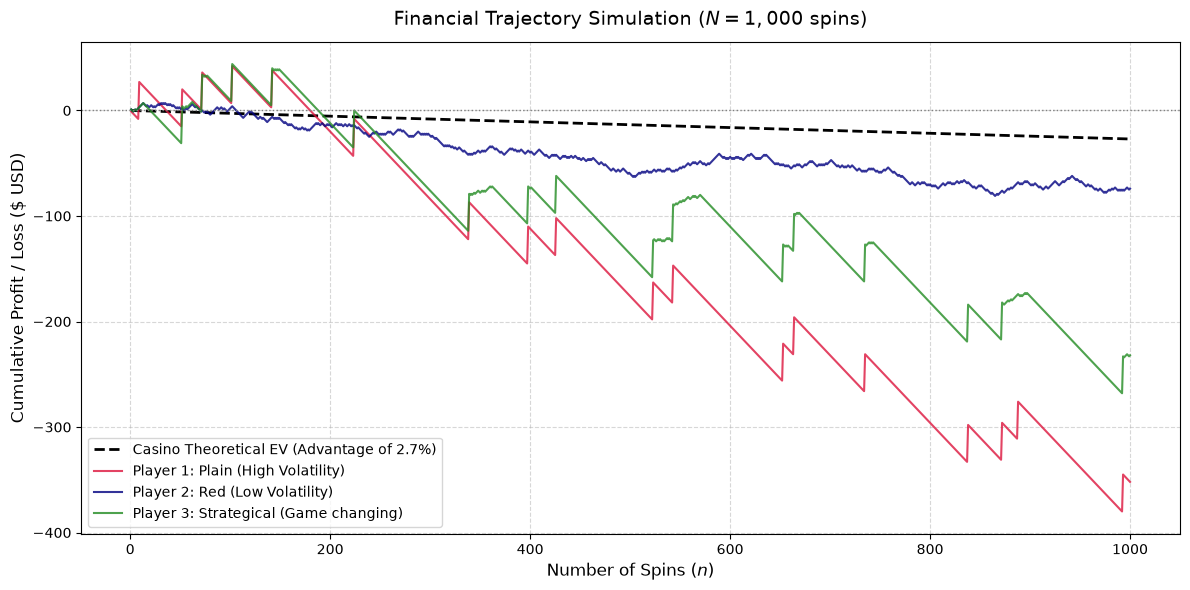

In [74]:
# X axis
spin_axis = np.arange(1, n_times + 1)

# Theoretical Expected Value
theoretical_ev = spin_axis * (-1 / 37)

# Setting the graph
plt.figure(figsize=(12, 6))

# Visualizing the theoretical line of casino's advantage
plt.plot(spin_axis, theoretical_ev, color='black', linestyle='--', linewidth=2, 
         label='Casino Theoretical EV (Advantage of 2.7%)')

# Visualizing the accumulated earnings of each player
plt.plot(spin_axis, earns_acum_one, label='Player 1: Plain (High Volatility)', alpha=0.8, color='crimson')
plt.plot(spin_axis, earns_acum_two, label='Player 2: Red (Low Volatility)', alpha=0.8, color='navy')
plt.plot(spin_axis, earns_acum_three, label='Player 3: Strategical (Game changing)', alpha=0.8, color='forestgreen')

# Graph design
plt.axhline(0, color='gray', linestyle=':', linewidth=1) # Point of equilibrium line (0 USD)
plt.title(f'Financial Trajectory Simulation ($N = {n_times:,}$ spins)', fontsize=14, pad=12)
plt.xlabel('Number of Spins ($n$)', fontsize=12)
plt.ylabel('Cumulative Profit / Loss ($ USD)', fontsize=12)
plt.legend(fontsize=10, loc='lower left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Turning everything into a DF for easy readability**

In [78]:
player_financial_earnings = pd.DataFrame({
    '# of Spin': spin_axis,
    'Wheel Numer': wheel_spins,
    'Player 1': earns_acum_one,
    'Player 2': earns_acum_two,
    'Player 3': earns_acum_three
})

player_financial_earnings

,# of Spin,Wheel Numer,Player 1,Player 2,Player 3
0,1,3,-1,1,1
1,2,28,-2,0,0
2,3,24,-3,-1,-1
3,4,16,-4,0,0
4,5,16,-5,1,1
...,...,...,...,...,...
995,996,23,-348,-74,-232
996,997,19,-349,-73,-231
997,998,13,-350,-74,-232
998,999,35,-351,-75,-233


## 4.3 Using SciPy for massive simulation and theoretical curve

In [87]:
# 1. Parameters
EXPERIMENTS = 5000
SPINS = 1000
SEED = 42

rng = np.random.default_rng(SEED)

--- Theoretical Analysis with scipy.stats.norm for N = 1000 spins ---
Total Expected Value (Mean): $-27.03 USD
Standard Deviation (Accumulated): $31.61 USD
Probability of Player Winning (Positive Balance): 19.63%
Probability of Casino Winning (Negative Balance): 80.37%
95% Confidence Interval for Results: [$-88.98, $34.93] USD


<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\s'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\s'
/var/folders/g2/zqzrlncd04d_z22w7bjxplz40000gn/T/ipykernel_2321/4065333297.py:42: SyntaxWarning: invalid escape sequence '\m'
  label=f'Theoretical Normal CLT Curve\n$\mathcal{{N}}(\mu={mu_tlc:.1f}, \sigma={sigma_tlc:.1f})$')
/var/folders/g2/zqzrlncd04d_z22w7bjxplz40000gn/T/ipykernel_2321/4065333297.py:42: SyntaxWarning: invalid escape sequence '\m'
  label=f'Theoretical Normal CLT Curve\n$\mathcal{{N}}(\mu={mu_tlc:.1f}, \sigma={sigma_tlc:.1f})$')
/var/folders/g2/zqzrlncd04d_z22w7bjxplz40000gn/T/ipykernel_2321/4065333297.py:42: SyntaxWarning: invalid escape sequence '\s'
  label=f'Theoretical Normal CLT Curve\n$\mathcal{{N}}(\mu={mu_tlc:.1f}, \sigma={sigma_tlc:.1f})$')


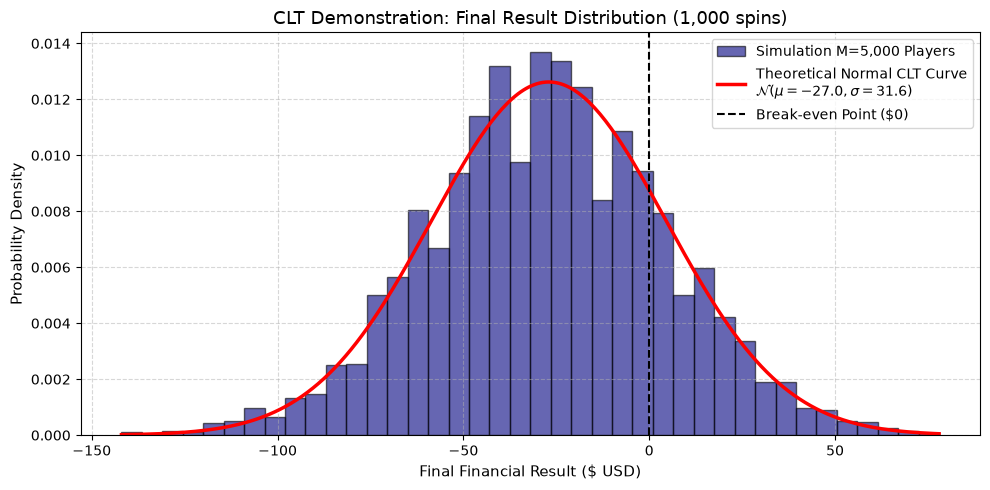

In [91]:
# 2. Simulating a results matrix for Player 2 (Conservative)
win_probe = 18 / 37
payments_red = rng.choice([1, -1], size=(EXPERIMENTS, SPINS), p=[win_probe, 1 - win_probe])

# 3. Calculating the cumulative final result ($) of each player after N spins
final_results = payments_red.sum(axis=1)

# 4. Theoretical Parameters for TLC over N spins
mu_spin = (1 * 18/37) + (-1 * 19/37)       # -0.027027 USD
var_spin = ((1 - mu_spin)**2 * 18/37) + ((-1 - mu_spin)**2 * 19/37)
sigma_spin = np.sqrt(var_spin)

# Theoretical Parameters for the Normal Distribution for the TOTAL SUM after N spins:
mu_tlc = SPINS * mu_spin                 # -27.027 USD
sigma_tlc = sigma_spin * np.sqrt(SPINS)  # Accumulated Volatility


# 5. SciPy Normal Distribution Analysis
prob_player_wins = 1 - stats.norm.cdf(0, loc=mu_tlc, scale=sigma_tlc)
ic_95 = stats.norm.interval(0.95, loc=mu_tlc, scale=sigma_tlc)

print(f"--- Theoretical Analysis with scipy.stats.norm for N = {SPINS} spins ---")
print(f"Total Expected Value (Mean): ${mu_tlc:.2f} USD")
print(f"Standard Deviation (Accumulated): ${sigma_tlc:.2f} USD")
print(f"Probability of Player Winning (Positive Balance): {prob_player_wins * 100:.2f}%")
print(f"Probability of Casino Winning (Negative Balance): {(1 - prob_player_wins) * 100:.2f}%")
print(f"95% Confidence Interval for Results: [${ic_95[0]:.2f}, ${ic_95[1]:.2f}] USD")

# 6. Graphical representation of the CLT Histogram
plt.figure(figsize=(10, 5))

# Histograma empírico de los M jugadores
count, bins, ignored = plt.hist(final_results, bins=40, density=True, 
                                alpha=0.6, color='navy', edgecolor='black', 
                                label=f'Simulation M={EXPERIMENTS:,} Players')

# Theoretical Curve of the CLT with norm.pdf
x_eje = np.linspace(final_results.min(), final_results.max(), 300)
pdf_teorica = stats.norm.pdf(x_eje, loc=mu_tlc, scale=sigma_tlc)

plt.plot(x_eje, pdf_teorica, 'r-', linewidth=2.5, 
         label=f'Theoretical Normal CLT Curve\n$\mathcal{{N}}(\mu={mu_tlc:.1f}, \sigma={sigma_tlc:.1f})$')

# Rentability line at 0 USD
plt.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Break-even Point ($0)')

plt.title(f'CLT Demonstration: Final Result Distribution ({SPINS:,} spins)', fontsize=13)
plt.xlabel('Final Financial Result ($ USD)', fontsize=11)
plt.ylabel('Probability Density', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()